# EDA US Stocks 2020-2024

## Brief Introduction to The Stock Market

### Stocks and Assets

In [11]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import KFold
from IPython.display import HTML, display
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

stocks = pd.read_csv("C:/Users/ckhin/OneDrive/Documents/GitHub/MATB-STUDIOS/US Stock Market Dataset.csv", index_col = 'Date', parse_dates=True)
stocks.head()

,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Price,Bitcoin_Vol.,Platinum_Price,...,Berkshire_Price,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Price,Gold_Vol.
Date,,,,,,,,,,,,,,,,,,,,,
2/2/2024,0,2.079,NaN,72.28,NaN,3.8215,NaN,"43,194.70",42650,901.6,...,"5,89,498",10580,564.64,4030000,171.81,117220000,474.99,84710000,"2,053.70",NaN
1/2/2024,1,2.050,161340.0,73.82,577940.0,3.8535,NaN,"43,081.40",47690,922.3,...,"5,81,600",9780,567.51,3150000,159.28,66360000,394.78,25140000,"2,071.10",260920.0
31-01-2024,2,2.100,142860.0,75.85,344490.0,3.9060,NaN,"42,580.50",56480,932.6,...,"5,78,020",9720,564.11,4830000,155.20,49690000,390.14,20010000,"2,067.40",238370.0
30-01-2024,3,2.077,139750.0,77.82,347240.0,3.9110,NaN,"42,946.20",55130,931.7,...,"5,84,680",9750,562.85,6120000,159.00,42290000,400.06,18610000,"2,050.90",214590.0
29-01-2024,4,2.490,3590.0,76.78,331930.0,3.8790,NaN,"43,299.80",45230,938.3,...,"5,78,800",13850,575.79,6880000,161.26,42840000,401.02,17790000,"2,034.90",1780.0


In [12]:
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 20

In [13]:
#output basic info on the dataset
print(stocks.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1013 entries, 2/2/2024 to 2/1/2020
Data columns (total 38 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1013 non-null   int64  
 1   Natural_Gas_Price  1013 non-null   float64
 2   Natural_Gas_Vol.   1009 non-null   float64
 3   Crude_oil_Price    1013 non-null   float64
 4   Crude_oil_Vol.     990 non-null    float64
 5   Copper_Price       1013 non-null   float64
 6   Copper_Vol.        976 non-null    float64
 7   Bitcoin_Price      1013 non-null   object 
 8   Bitcoin_Vol.       1013 non-null   int64  
 9   Platinum_Price     1013 non-null   object 
 10  Platinum_Vol.      636 non-null    float64
 11  Ethereum_Price     1013 non-null   object 
 12  Ethereum_Vol.      1013 non-null   int64  
 13  S&P_500_Price      1013 non-null   object 
 14  Nasdaq_100_Price   1013 non-null   object 
 15  Nasdaq_100_Vol.    1012 non-null   float64
 16  Apple_Price       

From the summary of the dataset, we can see that there is 13 numerical data and 7 categorical data. There are 1013 samples from the population. We chose to sample 70% of the dataset as the training set for our model. The rest of the 30% will be tested against our trained data to determine the model's predictability.

Unnamed: 0             0
Natural_Gas_Price      0
Natural_Gas_Vol.       4
Crude_oil_Price        0
Crude_oil_Vol.        23
Copper_Price           0
Copper_Vol.           37
Bitcoin_Price          0
Bitcoin_Vol.           0
Platinum_Price         0
Platinum_Vol.        377
Ethereum_Price         0
Ethereum_Vol.          0
S&P_500_Price          0
Nasdaq_100_Price       0
Nasdaq_100_Vol.        1
Apple_Price            0
Apple_Vol.             0
Tesla_Price            0
Tesla_Vol.             0
Microsoft_Price        0
Microsoft_Vol.         0
Silver_Price           0
Silver_Vol.           46
Google_Price           0
Google_Vol.            0
Nvidia_Price           0
Nvidia_Vol.            0
Berkshire_Price        0
Berkshire_Vol.         0
Netflix_Price          0
Netflix_Vol.           0
Amazon_Price           0
Amazon_Vol.            0
Meta_Price             0
Meta_Vol.              0
Gold_Price             0
Gold_Vol.              2
dtype: int64


((7,), <Axes: >)

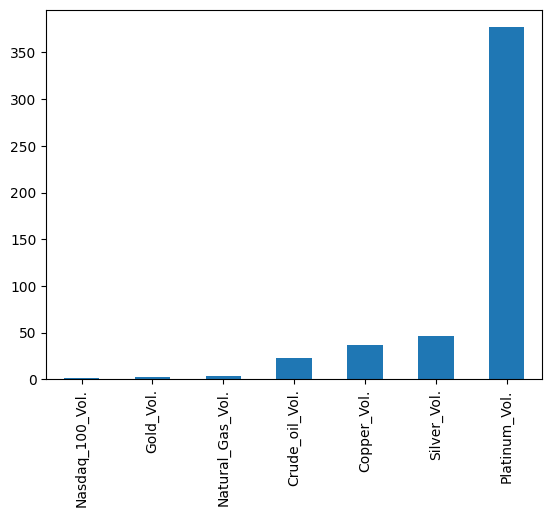

In [14]:
missing = stocks.isnull().sum() #sum up all the missing columns in a row
print(missing)
missing = missing[missing>0] #only shows missing data that are prevalent
missing.sort_values(inplace = True) #ordered sort

missing.shape, missing.plot.bar()

Evidently, there are 7 stocks / assets that have missing data with Platinum as the leading asset for most missing data. A newsletter claims that investors are losing interest in the metal due to global shortage of platinum. One of the potential reasons that may have caused the crisis includes frequent electricity cuts on South Africa, the country with the most platinum output ([Source](https://www.nasdaq.com/articles/why-does-platinum-keep-failing)). Nonetheless, Our approach to handling missing data is to perform K-Nearest Neighbours Algorithm (KNN) and fill up data that is missing.

### [K-Nearest Neighbours Algorithm (KNN)](https://www.ibm.com/topics/knn)

KNN is a supervised, non-parametric machine learning model that groups data with similar characteristics, providing predictions based on nearest euclidean distance (Note that not every classification task uses euclidean distance, alternative metrics are available) (Zhang et al, 2017). 

- supervised: Series of input and output data is first specified prior to performing actual predictions
- non-parametric: Makes limited assumptions about the underlying data

We start off by selecting columns with numerical data only.

In [15]:
numeric_columns = stocks.select_dtypes(include = [np.number, 'float']).columns.to_list()
selected_stocks = stocks[numeric_columns]

Furthermore, we apply KNN Imputer to fill in missing data:

In [16]:
knn = KNNImputer(n_neighbors = 5)
filled_stocks = knn.fit_transform(selected_stocks)
filled_df = pd.DataFrame(filled_stocks, columns = numeric_columns)

In [17]:
print(filled_df.head())

   Unnamed: 0  Natural_Gas_Price  Natural_Gas_Vol.  Crude_oil_Price  \
0         0.0              2.079          103180.0            72.28   
1         1.0              2.050          161340.0            73.82   
2         2.0              2.100          142860.0            75.85   
3         3.0              2.077          139750.0            77.82   
4         4.0              2.490            3590.0            76.78   

   Crude_oil_Vol.  Copper_Price  Copper_Vol.  Bitcoin_Vol.  Platinum_Vol.  \
0        341868.0        3.8215      57098.0       42650.0        11374.0   
1        577940.0        3.8535      34040.0       47690.0        15338.0   
2        344490.0        3.9060      89628.0       56480.0        23272.0   
3        347240.0        3.9110      78758.0       55130.0        26162.0   
4        331930.0        3.8790      76524.0       45230.0        25820.0   

   Ethereum_Vol.  ...  Nvidia_Price  Nvidia_Vol.  Berkshire_Vol.  \
0       246890.0  ...        661.60   4766

In [19]:
filled_df.head()

,Unnamed: 0,Natural_Gas_Price,Natural_Gas_Vol.,Crude_oil_Price,Crude_oil_Vol.,Copper_Price,Copper_Vol.,Bitcoin_Vol.,Platinum_Vol.,Ethereum_Vol.,...,Nvidia_Price,Nvidia_Vol.,Berkshire_Vol.,Netflix_Price,Netflix_Vol.,Amazon_Price,Amazon_Vol.,Meta_Price,Meta_Vol.,Gold_Vol.
0,0.0,2.079,103180.0,72.28,341868.0,3.8215,57098.0,42650.0,11374.0,246890.0,...,661.60,47660000.0,10580.0,564.64,4030000.0,171.81,117220000.0,474.99,84710000.0,190762.0
1,1.0,2.050,161340.0,73.82,577940.0,3.8535,34040.0,47690.0,15338.0,323610.0,...,630.27,36020000.0,9780.0,567.51,3150000.0,159.28,66360000.0,394.78,25140000.0,260920.0
2,2.0,2.100,142860.0,75.85,344490.0,3.9060,89628.0,56480.0,23272.0,408790.0,...,615.27,45070000.0,9720.0,564.11,4830000.0,155.20,49690000.0,390.14,20010000.0,238370.0
3,3.0,2.077,139750.0,77.82,347240.0,3.9110,78758.0,55130.0,26162.0,387120.0,...,627.74,39600000.0,9750.0,562.85,6120000.0,159.00,42290000.0,400.06,18610000.0,214590.0
4,4.0,2.490,3590.0,76.78,331930.0,3.8790,76524.0,45230.0,25820.0,318840.0,...,624.65,33900000.0,13850.0,575.79,6880000.0,161.26,42840000.0,401.02,17790000.0,1780.0
